# 04 — Baseline Models with Cross-Validation
**Aviation Safety Risk Prediction — NTSB + NOAA Dataset**

Six classifiers are compared on the matrices produced by NB03 (post-accident variables and
missingness indicators excluded, temporal split: train 2008–2018, val 2019–2021, test 2022 →):
Logistic Regression, Random Forest, XGBoost, LightGBM, CatBoost and an MLP.

### Protocol
1. **5-fold stratified cross-validation on the training set** — stable comparison (mean ± std)
2. **Final training** on the full training set; early stopping (boosting models) on the validation set
3. **Model selection** on the validation set
4. **One evaluation of the selected model on the held-out test set**

### Class imbalance
`NONE` represents more than half of the events. Every model receives *balanced* class weights
(`class_weight` or equivalent `sample_weight` — never both, which would square the weights).

### Priority metric
**FATL recall** — missing a fatal accident is far worse than a false alarm in a safety system.
Macro-F1 is reported alongside it: a model that predicts `FATL` everywhere would reach a perfect
FATL recall with a useless macro-F1.

### Outputs (`notebooks/baseline_models/`)
One `.pkl` per model, `best_model.pkl`, `cv_results.csv`, `val_comparison.csv` and figures.

In [1]:
# Environment check — these versions must match requirements.txt:
# a pickled model can only be reloaded reliably with the library version that created it.
import sys
import sklearn, xgboost, lightgbm, catboost

print('Python   :', sys.version.split()[0], '|', sys.executable)
for lib in (sklearn, xgboost, lightgbm, catboost):
    print(f'{lib.__name__:9s}: {lib.__version__}')

Python   : 3.12.8 | C:\Users\hp\Desktop\PFA\aviation-risk-predictor\.venv\Scripts\python.exe
sklearn  : 1.7.2
xgboost  : 2.1.1
lightgbm : 4.3.0
catboost : 1.2.10


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, time, warnings, re
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score, roc_auc_score)
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

SEED       = 42
OUTPUT_DIR = 'outputs'
MODEL_DIR  = 'baseline_models'
os.makedirs(MODEL_DIR, exist_ok=True)

LABEL_MAP   = {0:'NONE',1:'MINR',2:'SERS',3:'FATL'}
LABEL_NAMES = ['NONE','MINR','SERS','FATL']
CLASS_ORDER = [0,1,2,3]
N_CV_FOLDS  = 5


## 1. Load Data

In [3]:
X_train_raw = pd.read_csv(f'{OUTPUT_DIR}/X_train.csv')
X_val_raw   = pd.read_csv(f'{OUTPUT_DIR}/X_val.csv')
X_test_raw  = pd.read_csv(f'{OUTPUT_DIR}/X_test.csv')

y_train = pd.read_csv(f'{OUTPUT_DIR}/y_train.csv').squeeze()
y_val   = pd.read_csv(f'{OUTPUT_DIR}/y_val.csv').squeeze()
y_test  = pd.read_csv(f'{OUTPUT_DIR}/y_test.csv').squeeze()

class_weights = joblib.load(f'{OUTPUT_DIR}/class_weights.pkl')
sample_weights_train = compute_sample_weight(class_weight=class_weights, y=y_train)

print(f'X_train: {X_train_raw.shape}')
print(f'X_val  : {X_val_raw.shape}')
print(f'X_test : {X_test_raw.shape}')
print(f'y_train dist: {dict(y_train.value_counts().sort_index().rename(LABEL_MAP))}')


X_train: (22329, 375)
X_val  : (5717, 375)
X_test : (8214, 375)
y_train dist: {'NONE': 11828, 'MINR': 3075, 'SERS': 2637, 'FATL': 4789}


In [4]:
# ── LightGBM column sanitization — done ONCE at load time ────────────────
# Column names with brackets/special chars cause LightGBM's C API to error.
# We build clean versions once and use them consistently everywhere.

def sanitize_lgb_columns(df):
    """Replace any character that LightGBM rejects with underscore, then
    deduplicate column names that become identical after sanitization."""
    df = df.copy()
    new_cols = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    seen = {}
    deduped = []
    for col in new_cols:
        if col in seen:
            seen[col] += 1
            deduped.append(f'{col}_{seen[col]}')
        else:
            seen[col] = 0
            deduped.append(col)
    df.columns = deduped
    return df

X_train_lgb = sanitize_lgb_columns(X_train_raw)
X_val_lgb   = sanitize_lgb_columns(X_val_raw)
X_test_lgb  = sanitize_lgb_columns(X_test_raw)

# Standard (non-LGB) arrays — use as-is
X_train = X_train_raw.values
X_val   = X_val_raw.values
X_test  = X_test_raw.values

print(f'LGB sanitized X_train: {X_train_lgb.shape}')
print('Column sanitization done ✓ — using X_train_lgb / X_train variants throughout')


LGB sanitized X_train: (22329, 375)
Column sanitization done ✓ — using X_train_lgb / X_train variants throughout


## 2. Helper Functions

In [5]:
def evaluate_model(model, X, y_true, split_name='val', model_name='',
                   is_lgb=False):
    """Evaluate on a single split. Returns metrics dict."""
    X_eval = X  # already the right version (lgb or standard)
    y_pred = model.predict(X_eval)

    try:
        y_prob = model.predict_proba(X_eval)
        auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    except Exception:
        auc = np.nan

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc      = accuracy_score(y_true, y_pred)
    report   = classification_report(y_true, y_pred, output_dict=True,
                                     target_names=LABEL_NAMES, zero_division=0)
    fatl_f1  = report.get('FATL', {}).get('f1-score', np.nan)
    fatl_rec = report.get('FATL', {}).get('recall',   np.nan)

    print(f'\n{"="*55}')
    print(f'  {model_name} — {split_name.upper()} SET')
    print(f'{"="*55}')
    print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, zero_division=0))
    print(f'  Macro F1  : {macro_f1:.4f}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  AUC (OvR) : {auc:.4f}')
    print(f'  FATL F1   : {fatl_f1:.4f}  ← priority metric')
    print(f'  FATL Rec  : {fatl_rec:.4f}  ← how many fatals we catch')

    return dict(model=model_name, split=split_name, macro_f1=macro_f1,
                accuracy=acc, auc=auc, fatl_f1=fatl_f1, fatl_recall=fatl_rec)


def plot_confusion_matrix(model, X, y_true, model_name, split_name='val'):
    y_pred = model.predict(X)
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER, normalize='true')
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{model_name} — Confusion Matrix ({split_name})', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{MODEL_DIR}/cm_{model_name.replace(" ","_").lower()}_{split_name}.png', dpi=150)
    plt.show()

print('Helper functions defined ✓')


Helper functions defined ✓


## 3. Cross-Validation Scoring
5-fold stratified CV is run on `X_train` only (2008–2018) **before** final training, to:
- compare models on stable metrics (mean ± std over the folds)
- rank them by FATL recall while keeping an eye on macro-F1

The folds are shuffled *within* the training years: CV compares model families on the same
period, while the temporal generalisation is measured on the later validation (2019–2021) and
test (2022 →) years.

In [6]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

cv_skf = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=SEED)

# We define a FATL-recall scorer and macro-F1 scorer
from sklearn.metrics import make_scorer, recall_score

def fatl_recall_scorer(y_true, y_pred):
    """Recall for class 3 (FATL)."""
    return recall_score(y_true, y_pred, labels=[3], average='macro', zero_division=0)

scoring = {
    'macro_f1':    make_scorer(f1_score, average='macro', zero_division=0),
    'fatl_recall': make_scorer(fatl_recall_scorer),
    'accuracy':    'accuracy',
}


In [7]:
# Define model blueprints for CV (not yet fitted)
cat_class_weights_list = [class_weights[i] for i in CLASS_ORDER]

model_blueprints = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, class_weight=class_weights,
        solver='lbfgs', random_state=SEED, n_jobs=-1),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        max_features='sqrt', class_weight=class_weights,
        random_state=SEED, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
        objective='multi:softprob', num_class=4, eval_metric='mlogloss',
        use_label_encoder=False, random_state=SEED, n_jobs=-1, verbosity=0),
    'CatBoost': CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.05, l2_leaf_reg=3,
        class_weights=[float(class_weights[i]) for i in CLASS_ORDER],  # ← fix
        loss_function='MultiClass', random_seed=SEED, verbose=0),
}
# Note: LightGBM and MLP require special handling (sanitized cols / sample_weight)
# so they are cross-validated manually below.

cv_results = {}

for name, blueprint in model_blueprints.items():
    print(f'CV — {name}...')
    t0 = time.time()
    scores = {'macro_f1': [], 'fatl_recall': [], 'accuracy': []}

    for fold, (tr_idx, val_idx) in enumerate(cv_skf.split(X_train, y_train)):
        Xtr, ytr = X_train[tr_idx], y_train.iloc[tr_idx]
        Xvl, yvl = X_train[val_idx], y_train.iloc[val_idx]
        sw_tr = sample_weights_train[tr_idx]

        # CatBoost doesn't support clone() — reinstantiate directly
        if name == 'CatBoost':
            m = CatBoostClassifier(
                iterations=300, depth=6, learning_rate=0.05, l2_leaf_reg=3,
                class_weights=[float(class_weights[i]) for i in CLASS_ORDER],
                loss_function='MultiClass', random_seed=SEED, verbose=0)
        else:
            m = clone(blueprint)

        if name == 'XGBoost':
            m.fit(Xtr, ytr, sample_weight=sw_tr)
        else:
            m.fit(Xtr, ytr)

        ypred = m.predict(Xvl)
        scores['macro_f1'].append(f1_score(yvl, ypred, average='macro', zero_division=0))
        scores['fatl_recall'].append(fatl_recall_scorer(yvl, ypred))
        scores['accuracy'].append(accuracy_score(yvl, ypred))

    elapsed = time.time() - t0
    cv_results[name] = {
        'macro_f1_mean':    np.mean(scores['macro_f1']),
        'macro_f1_std':     np.std(scores['macro_f1']),
        'fatl_recall_mean': np.mean(scores['fatl_recall']),
        'fatl_recall_std':  np.std(scores['fatl_recall']),
        'accuracy_mean':    np.mean(scores['accuracy']),
        'accuracy_std':     np.std(scores['accuracy']),
    }
    print(f'  macro_f1={cv_results[name]["macro_f1_mean"]:.4f}±{cv_results[name]["macro_f1_std"]:.4f}'
          f'  fatl_recall={cv_results[name]["fatl_recall_mean"]:.4f}±{cv_results[name]["fatl_recall_std"]:.4f}'
          f'  ({elapsed:.0f}s)')

CV — Logistic Regression...


  macro_f1=0.4530±0.0059  fatl_recall=0.6273±0.0175  (124s)
CV — Random Forest...


  macro_f1=0.5006±0.0073  fatl_recall=0.6640±0.0164  (75s)
CV — XGBoost...


  macro_f1=0.5243±0.0059  fatl_recall=0.7306±0.0060  (127s)
CV — CatBoost...


  macro_f1=0.4820±0.0061  fatl_recall=0.6866±0.0078  (128s)


In [8]:
# Manual CV for LightGBM (sanitized columns)
print('CV — LightGBM (manual)...')
t0 = time.time()
lgb_cv_scores = {'macro_f1': [], 'fatl_recall': [], 'accuracy': []}

for fold, (tr_idx, val_idx) in enumerate(cv_skf.split(X_train_lgb, y_train)):
    Xtr = X_train_lgb.iloc[tr_idx]; ytr = y_train.iloc[tr_idx]
    Xvl = X_train_lgb.iloc[val_idx]; yvl = y_train.iloc[val_idx]

    m = lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
        reg_alpha=0.1, reg_lambda=1.0, class_weight=class_weights,
        objective='multiclass', num_class=4, metric='multi_logloss',
        random_state=SEED, n_jobs=-1, verbose=-1)
    # class_weight is already set above: passing sample_weight as well would
    # square the weights (bug of the previous version: CV macro-F1 0.50 vs 0.59 on val)
    m.fit(Xtr, ytr,
          eval_set=[(Xvl, yvl)],
          callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(period=-1)])
    ypred = m.predict(Xvl)
    lgb_cv_scores['macro_f1'].append(f1_score(yvl, ypred, average='macro', zero_division=0))
    lgb_cv_scores['fatl_recall'].append(fatl_recall_scorer(yvl, ypred))
    lgb_cv_scores['accuracy'].append(accuracy_score(yvl, ypred))
    print(f'  fold {fold+1}: macro_f1={lgb_cv_scores["macro_f1"][-1]:.4f}  fatl_recall={lgb_cv_scores["fatl_recall"][-1]:.4f}')

cv_results['LightGBM'] = {
    'macro_f1_mean':    np.mean(lgb_cv_scores['macro_f1']),
    'macro_f1_std':     np.std(lgb_cv_scores['macro_f1']),
    'fatl_recall_mean': np.mean(lgb_cv_scores['fatl_recall']),
    'fatl_recall_std':  np.std(lgb_cv_scores['fatl_recall']),
    'accuracy_mean':    np.mean(lgb_cv_scores['accuracy']),
    'accuracy_std':     np.std(lgb_cv_scores['accuracy']),
}
print(f'LightGBM CV: macro_f1={cv_results["LightGBM"]["macro_f1_mean"]:.4f}  '
      f'fatl_recall={cv_results["LightGBM"]["fatl_recall_mean"]:.4f}  ({time.time()-t0:.0f}s)')

CV — LightGBM (manual)...


  fold 1: macro_f1=0.5174  fatl_recall=0.7223


  fold 2: macro_f1=0.5275  fatl_recall=0.7234


  fold 3: macro_f1=0.5294  fatl_recall=0.7294


  fold 4: macro_f1=0.5261  fatl_recall=0.7223


  fold 5: macro_f1=0.5108  fatl_recall=0.7223
LightGBM CV: macro_f1=0.5223  fatl_recall=0.7240  (66s)


In [9]:
# Manual CV for MLP (sample_weight in fit, no internal val fraction)
print('CV — MLP (manual)...')
t0 = time.time()
mlp_cv_scores = {'macro_f1': [], 'fatl_recall': [], 'accuracy': []}

for fold, (tr_idx, val_idx) in enumerate(cv_skf.split(X_train, y_train)):
    Xtr = X_train[tr_idx]; ytr = y_train.iloc[tr_idx]
    Xvl = X_train[val_idx]; yvl = y_train.iloc[val_idx]
    sw_tr = sample_weights_train[tr_idx]

    m = MLPClassifier(
        hidden_layer_sizes=(256,128,64), activation='relu', solver='adam',
        alpha=0.001, batch_size=256, learning_rate='adaptive',
        learning_rate_init=0.001, max_iter=200,
        # No internal validation_fraction — fair comparison with other models
        early_stopping=False,
        random_state=SEED, verbose=False)
    m.fit(Xtr, ytr)
    ypred = m.predict(Xvl)
    mlp_cv_scores['macro_f1'].append(f1_score(yvl, ypred, average='macro', zero_division=0))
    mlp_cv_scores['fatl_recall'].append(fatl_recall_scorer(yvl, ypred))
    mlp_cv_scores['accuracy'].append(accuracy_score(yvl, ypred))
    print(f'  fold {fold+1}: macro_f1={mlp_cv_scores["macro_f1"][-1]:.4f}  fatl_recall={mlp_cv_scores["fatl_recall"][-1]:.4f}')

cv_results['MLP'] = {
    'macro_f1_mean':    np.mean(mlp_cv_scores['macro_f1']),
    'macro_f1_std':     np.std(mlp_cv_scores['macro_f1']),
    'fatl_recall_mean': np.mean(mlp_cv_scores['fatl_recall']),
    'fatl_recall_std':  np.std(mlp_cv_scores['fatl_recall']),
    'accuracy_mean':    np.mean(mlp_cv_scores['accuracy']),
    'accuracy_std':     np.std(mlp_cv_scores['accuracy']),
}
print(f'MLP CV: macro_f1={cv_results["MLP"]["macro_f1_mean"]:.4f}  '
      f'fatl_recall={cv_results["MLP"]["fatl_recall_mean"]:.4f}  ({time.time()-t0:.0f}s)')


CV — MLP (manual)...


  fold 1: macro_f1=0.4672  fatl_recall=0.5678


  fold 2: macro_f1=0.4621  fatl_recall=0.6033


  fold 3: macro_f1=0.4751  fatl_recall=0.5789


  fold 4: macro_f1=0.4710  fatl_recall=0.5647


  fold 5: macro_f1=0.4734  fatl_recall=0.5866
MLP CV: macro_f1=0.4698  fatl_recall=0.5803  (373s)



  CROSS-VALIDATION RESULTS (5-fold stratified)
              model  macro_f1_mean  macro_f1_std  fatl_recall_mean  fatl_recall_std  accuracy_mean  accuracy_std
            XGBoost         0.5243        0.0059            0.7306           0.0060         0.6073        0.0036
           LightGBM         0.5223        0.0070            0.7240           0.0027         0.6022        0.0058
           CatBoost         0.4820        0.0061            0.6866           0.0078         0.5493        0.0053
      Random Forest         0.5006        0.0073            0.6640           0.0164         0.6737        0.0035
Logistic Regression         0.4530        0.0059            0.6273           0.0175         0.5159        0.0049
                MLP         0.4698        0.0047            0.5803           0.0139         0.5846        0.0052


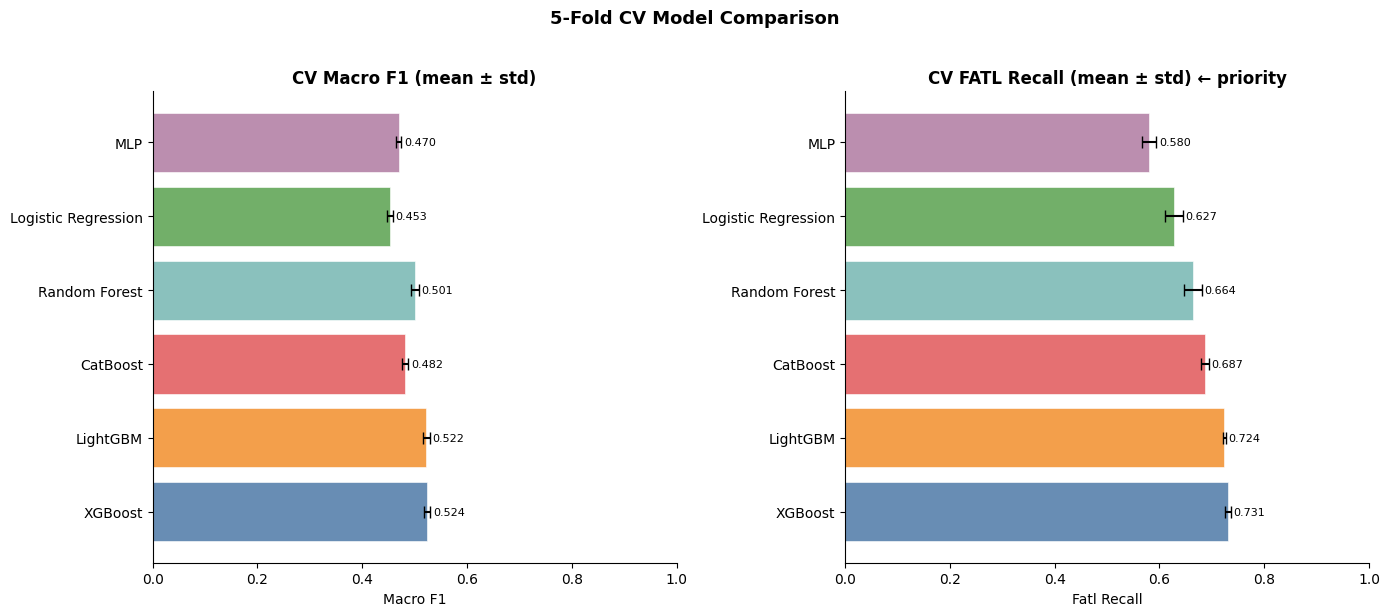

In [10]:
# CV Results table
cv_df = pd.DataFrame(cv_results).T.reset_index().rename(columns={'index':'model'})
cv_df = cv_df.sort_values('fatl_recall_mean', ascending=False).reset_index(drop=True)
cv_df = cv_df.round(4)
print('\n' + '='*70)
print('  CROSS-VALIDATION RESULTS (5-fold stratified)')
print('='*70)
print(cv_df.to_string(index=False))
cv_df.to_csv(f'{MODEL_DIR}/cv_results.csv', index=False)

# Plot: CV macro F1 and FATL recall with error bars
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors6 = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#b07aa1']

for ax, metric, title in zip(axes,
    ['macro_f1', 'fatl_recall'],
    ['CV Macro F1 (mean ± std)', 'CV FATL Recall (mean ± std) ← priority']):
    means = cv_df[f'{metric}_mean'].values
    stds  = cv_df[f'{metric}_std'].values
    labels= cv_df['model'].values
    y_pos = range(len(labels))
    ax.barh(y_pos, means, xerr=stds, color=colors6[:len(labels)],
            edgecolor='white', linewidth=0.5, capsize=4, alpha=0.85)
    ax.set_yticks(y_pos); ax.set_yticklabels(labels)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(metric.replace('_',' ').title())
    ax.set_xlim(0, 1)
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(m + s + 0.005, i, f'{m:.3f}', va='center', fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('5-Fold CV Model Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Train Final Models on Full Training Set

Training Logistic Regression on full train set...


Done in 27.7s

  Logistic Regression — VAL SET
              precision    recall  f1-score   support

        NONE       0.74      0.55      0.63      3010
        MINR       0.20      0.33      0.25       740
        SERS       0.30      0.40      0.34       727
        FATL       0.54      0.56      0.55      1240

    accuracy                           0.50      5717
   macro avg       0.44      0.46      0.44      5717
weighted avg       0.57      0.50      0.53      5717

  Macro F1  : 0.4410
  Accuracy  : 0.5024
  AUC (OvR) : 0.7189
  FATL F1   : 0.5478  ← priority metric
  FATL Rec  : 0.5565  ← how many fatals we catch


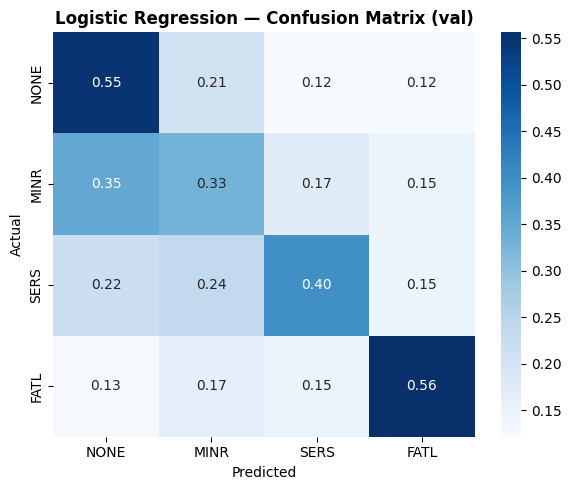

['baseline_models/logistic_regression.pkl']

In [11]:
print('Training Logistic Regression on full train set...')
t0 = time.time()
lr = LogisticRegression(C=1.0, max_iter=1000, class_weight=class_weights,
                        solver='lbfgs', random_state=SEED, n_jobs=-1)
lr.fit(X_train, y_train)
print(f'Done in {time.time()-t0:.1f}s')
metrics_lr_val = evaluate_model(lr, X_val, y_val, 'val', 'Logistic Regression')
plot_confusion_matrix(lr, X_val, y_val, 'Logistic Regression')
joblib.dump(lr, f'{MODEL_DIR}/logistic_regression.pkl')


Training Random Forest...


Done in 17.3s



  Random Forest — VAL SET
              precision    recall  f1-score   support

        NONE       0.62      0.87      0.73      3010
        MINR       0.36      0.01      0.02       740
        SERS       0.61      0.15      0.24       727
        FATL       0.57      0.60      0.58      1240

    accuracy                           0.61      5717
   macro avg       0.54      0.41      0.39      5717
weighted avg       0.58      0.61      0.54      5717

  Macro F1  : 0.3948
  Accuracy  : 0.6098
  AUC (OvR) : 0.7395
  FATL F1   : 0.5847  ← priority metric
  FATL Rec  : 0.5984  ← how many fatals we catch


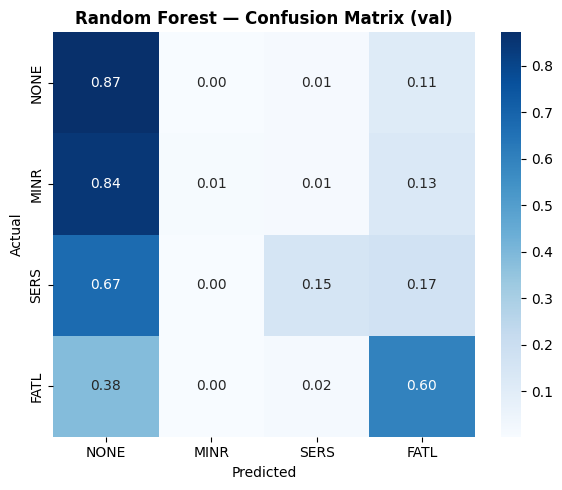

['baseline_models/random_forest.pkl']

In [12]:
print('Training Random Forest...')
t0 = time.time()
rf = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=2,
                             max_features='sqrt', class_weight=class_weights,
                             random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
print(f'Done in {time.time()-t0:.1f}s')
metrics_rf_val = evaluate_model(rf, X_val, y_val, 'val', 'Random Forest')
plot_confusion_matrix(rf, X_val, y_val, 'Random Forest')
joblib.dump(rf, f'{MODEL_DIR}/random_forest.pkl')


Training XGBoost...


Done in 69.0s  |  Best iter: 493



  XGBoost — VAL SET
              precision    recall  f1-score   support

        NONE       0.72      0.67      0.69      3010
        MINR       0.23      0.25      0.24       740
        SERS       0.35      0.27      0.31       727
        FATL       0.55      0.69      0.61      1240

    accuracy                           0.57      5717
   macro avg       0.46      0.47      0.46      5717
weighted avg       0.57      0.57      0.57      5717

  Macro F1  : 0.4633
  Accuracy  : 0.5680
  AUC (OvR) : 0.7511
  FATL F1   : 0.6150  ← priority metric
  FATL Rec  : 0.6944  ← how many fatals we catch


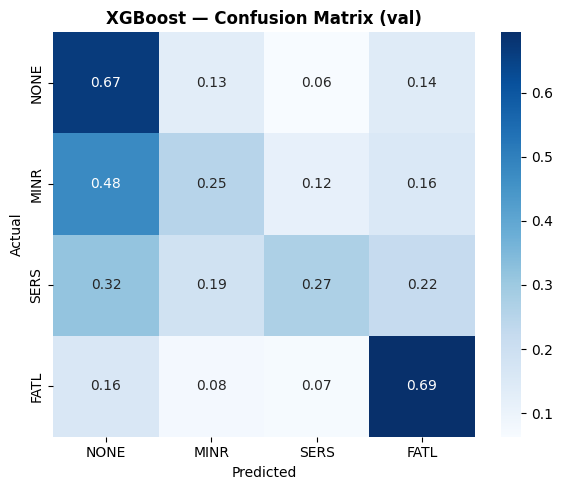

['baseline_models/xgboost.pkl']

In [13]:
print('Training XGBoost...')
t0 = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    objective='multi:softprob', num_class=4, eval_metric='mlogloss',
    use_label_encoder=False, random_state=SEED, n_jobs=-1, verbosity=0,
    early_stopping_rounds=30,
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weights_train,
              eval_set=[(X_val, y_val)], verbose=False)
print(f'Done in {time.time()-t0:.1f}s  |  Best iter: {xgb_model.best_iteration}')
metrics_xgb_val = evaluate_model(xgb_model, X_val, y_val, 'val', 'XGBoost')
plot_confusion_matrix(xgb_model, X_val, y_val, 'XGBoost')
joblib.dump(xgb_model, f'{MODEL_DIR}/xgboost.pkl')


Training LightGBM...


Done in 13.0s  |  Best iter: 296



  LightGBM — VAL SET
              precision    recall  f1-score   support

        NONE       0.74      0.62      0.67      3010
        MINR       0.23      0.31      0.26       740
        SERS       0.36      0.32      0.34       727
        FATL       0.56      0.69      0.62      1240

    accuracy                           0.56      5717
   macro avg       0.47      0.48      0.47      5717
weighted avg       0.58      0.56      0.57      5717

  Macro F1  : 0.4729
  Accuracy  : 0.5564
  AUC (OvR) : 0.7531
  FATL F1   : 0.6168  ← priority metric
  FATL Rec  : 0.6887  ← how many fatals we catch


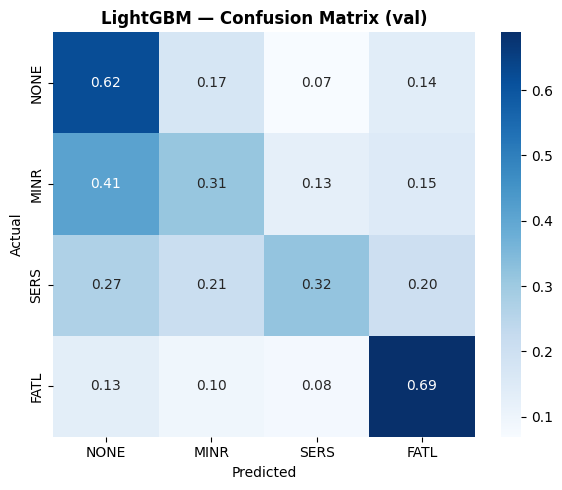

['baseline_models/lightgbm.pkl']

In [14]:
print('Training LightGBM...')
t0 = time.time()
lgb_model = lgb.LGBMClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
    reg_alpha=0.1, reg_lambda=1.0, class_weight=class_weights,
    objective='multiclass', num_class=4, metric='multi_logloss',
    random_state=SEED, n_jobs=-1, verbose=-1)
lgb_model.fit(
    X_train_lgb, y_train,
    eval_set=[(X_val_lgb, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(period=-1)])
print(f'Done in {time.time()-t0:.1f}s  |  Best iter: {lgb_model.best_iteration_}')
metrics_lgb_val = evaluate_model(lgb_model, X_val_lgb, y_val, 'val', 'LightGBM')
plot_confusion_matrix(lgb_model, X_val_lgb, y_val, 'LightGBM')
joblib.dump(lgb_model, f'{MODEL_DIR}/lightgbm.pkl')


Training CatBoost...


Done in 26.5s  |  Best iter: 313

  CatBoost — VAL SET
              precision    recall  f1-score   support

        NONE       0.75      0.56      0.64      3010
        MINR       0.22      0.36      0.27       740
        SERS       0.41      0.33      0.36       727
        FATL       0.53      0.69      0.60      1240

    accuracy                           0.54      5717
   macro avg       0.48      0.49      0.47      5717
weighted avg       0.59      0.54      0.55      5717

  Macro F1  : 0.4702
  Accuracy  : 0.5365
  AUC (OvR) : 0.7495
  FATL F1   : 0.6019  ← priority metric
  FATL Rec  : 0.6919  ← how many fatals we catch


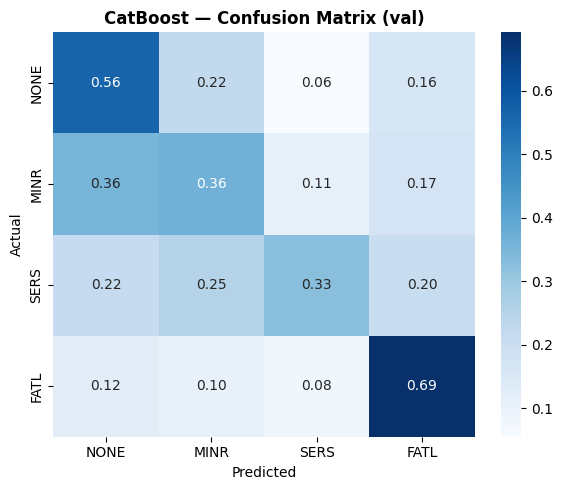

['baseline_models/catboost.pkl']

In [15]:
print('Training CatBoost...')
t0 = time.time()
cat_class_weights_list = [class_weights[i] for i in CLASS_ORDER]
cat_model = CatBoostClassifier(
    iterations=500, depth=6, learning_rate=0.05, l2_leaf_reg=3,
    class_weights=cat_class_weights_list,
    loss_function='MultiClass', eval_metric='MultiClass',
    random_seed=SEED, early_stopping_rounds=30, verbose=0)
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)
print(f'Done in {time.time()-t0:.1f}s  |  Best iter: {cat_model.best_iteration_}')
metrics_cat_val = evaluate_model(cat_model, X_val, y_val, 'val', 'CatBoost')
plot_confusion_matrix(cat_model, X_val, y_val, 'CatBoost')
joblib.dump(cat_model, f'{MODEL_DIR}/catboost.pkl')


Training MLP on FULL X_train (no internal validation fraction)...


Done in 134.3s  |  Iterations: 64

  MLP — VAL SET


              precision    recall  f1-score   support

        NONE       0.64      0.71      0.67      3010
        MINR       0.18      0.16      0.17       740
        SERS       0.28      0.27      0.27       727
        FATL       0.53      0.44      0.48      1240

    accuracy                           0.52      5717
   macro avg       0.41      0.40      0.40      5717
weighted avg       0.51      0.52      0.52      5717

  Macro F1  : 0.4011
  Accuracy  : 0.5239
  AUC (OvR) : 0.6731
  FATL F1   : 0.4848  ← priority metric
  FATL Rec  : 0.4444  ← how many fatals we catch


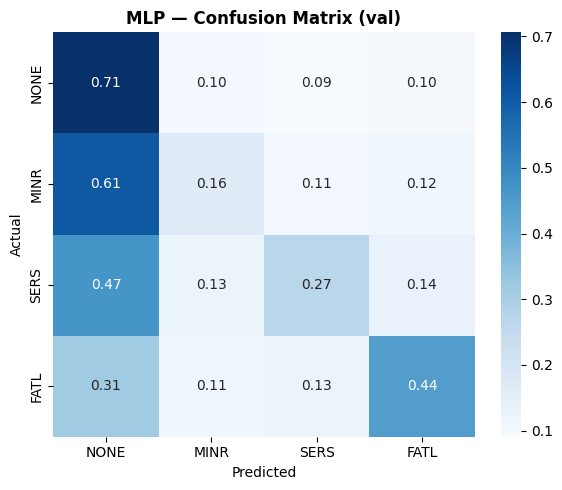

['baseline_models/mlp.pkl']

In [16]:
print('Training MLP on FULL X_train (no internal validation fraction)...')
t0 = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(256,128,64), activation='relu', solver='adam',
    alpha=0.001, batch_size=256, learning_rate='adaptive',
    learning_rate_init=0.001, max_iter=300,
    # No early_stopping / validation_fraction — MLP now trains on the
    # same proportion of data as all other models. We monitor convergence
    # via n_iter_no_change on training loss.
    early_stopping=False, n_iter_no_change=20,
    random_state=SEED, verbose=False)
mlp.fit(X_train, y_train)
print(f'Done in {time.time()-t0:.1f}s  |  Iterations: {mlp.n_iter_}')
metrics_mlp_val = evaluate_model(mlp, X_val, y_val, 'val', 'MLP')
plot_confusion_matrix(mlp, X_val, y_val, 'MLP')
joblib.dump(mlp, f'{MODEL_DIR}/mlp.pkl')


## 5. Validation Set Comparison

In [17]:
all_metrics = [metrics_lr_val, metrics_rf_val, metrics_xgb_val,
               metrics_lgb_val, metrics_cat_val, metrics_mlp_val]

results_df = pd.DataFrame(all_metrics).drop(columns=['split'])
results_df = results_df.sort_values('fatl_recall', ascending=False).reset_index(drop=True)
results_df[['macro_f1','accuracy','auc','fatl_f1','fatl_recall']] =     results_df[['macro_f1','accuracy','auc','fatl_f1','fatl_recall']].round(4)

print('\n' + '='*65)
print('  MODEL COMPARISON — VALIDATION SET (sorted by FATL recall)')
print('='*65)
print(results_df.to_string(index=False))
results_df.to_csv(f'{MODEL_DIR}/val_comparison.csv', index=False)



  MODEL COMPARISON — VALIDATION SET (sorted by FATL recall)
              model  macro_f1  accuracy    auc  fatl_f1  fatl_recall
            XGBoost    0.4633    0.5680 0.7511   0.6150       0.6944
           CatBoost    0.4702    0.5365 0.7495   0.6019       0.6919
           LightGBM    0.4729    0.5564 0.7531   0.6168       0.6887
      Random Forest    0.3948    0.6098 0.7395   0.5847       0.5984
Logistic Regression    0.4410    0.5024 0.7189   0.5478       0.5565
                MLP    0.4011    0.5239 0.6731   0.4848       0.4444


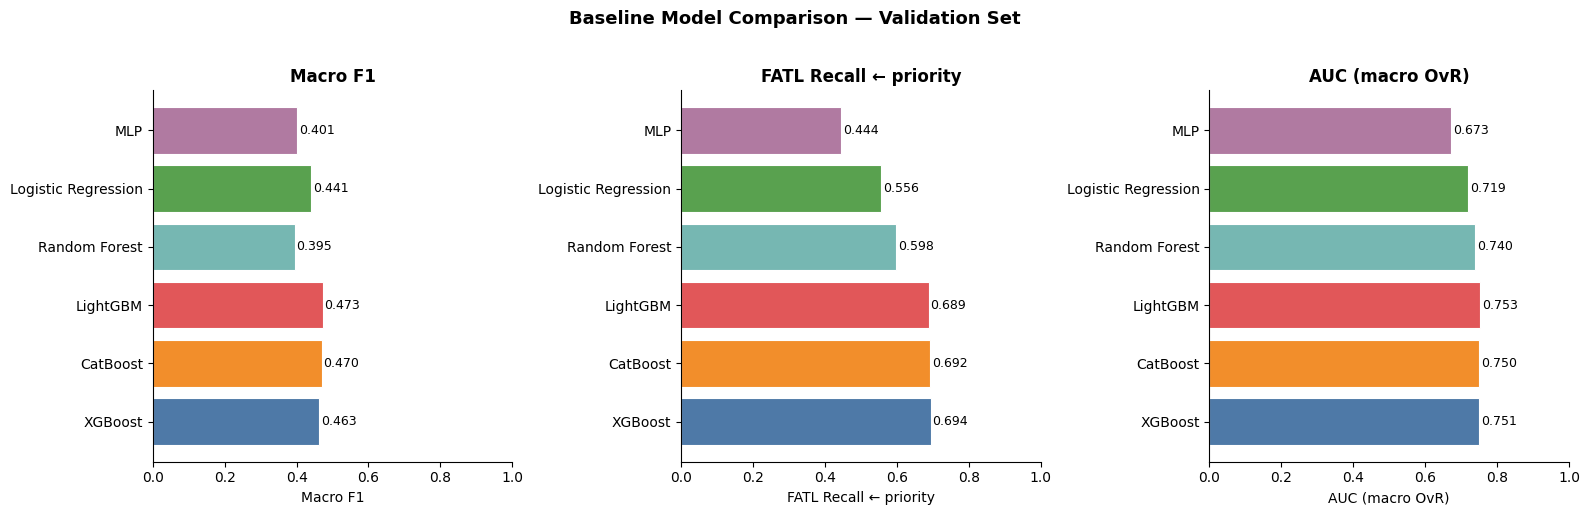

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ['macro_f1', 'fatl_recall', 'auc']
titles = ['Macro F1', 'FATL Recall ← priority', 'AUC (macro OvR)']
colors6 = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#b07aa1']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    bars = ax.barh(results_df['model'], results_df[metric],
                   color=colors6[:len(results_df)], edgecolor='white', linewidth=0.8)
    ax.set_xlabel(title); ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    sns.despine(ax=ax)

plt.suptitle('Baseline Model Comparison — Validation Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Final Evaluation on Held-Out Test Set

Best model (by FATL recall on val): XGBoost
Evaluating on HELD-OUT TEST SET...




  XGBoost — TEST SET
              precision    recall  f1-score   support

        NONE       0.71      0.69      0.70      4587
        MINR       0.25      0.27      0.26      1104
        SERS       0.42      0.33      0.37      1056
        FATL       0.48      0.56      0.52      1467

    accuracy                           0.56      8214
   macro avg       0.46      0.46      0.46      8214
weighted avg       0.57      0.56      0.56      8214

  Macro F1  : 0.4606
  Accuracy  : 0.5637
  AUC (OvR) : 0.7271
  FATL F1   : 0.5169  ← priority metric
  FATL Rec  : 0.5644  ← how many fatals we catch


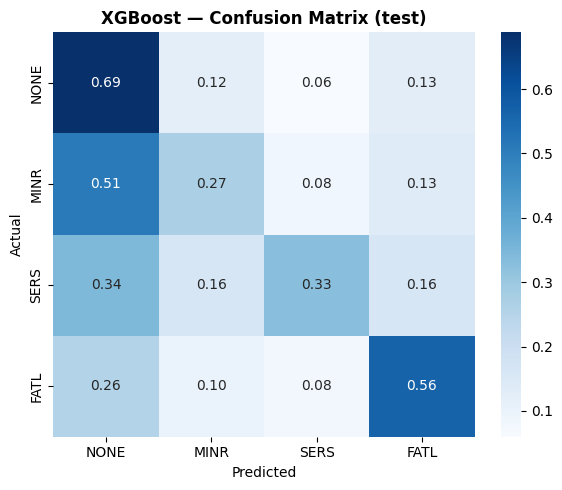


Best model saved to baseline_models/best_model.pkl
→ Will be wrapped with conformal prediction in 05_uncertainty.ipynb


In [19]:
best_model_name = results_df.iloc[0]['model']
model_map = {
    'Logistic Regression': lr,
    'Random Forest':        rf,
    'XGBoost':              xgb_model,
    'LightGBM':             lgb_model,
    'CatBoost':             cat_model,
    'MLP':                  mlp,
}
best_model = model_map[best_model_name]

# Use the right X_test version
X_test_for_best = X_test_lgb if best_model_name == 'LightGBM' else X_test

print(f'Best model (by FATL recall on val): {best_model_name}')
print('Evaluating on HELD-OUT TEST SET...\n')
metrics_test = evaluate_model(best_model, X_test_for_best, y_test, 'test', best_model_name)
plot_confusion_matrix(best_model, X_test_for_best, y_test, best_model_name, split_name='test')

joblib.dump(best_model, f'{MODEL_DIR}/best_model.pkl')
print(f'\nBest model saved to {MODEL_DIR}/best_model.pkl')
print('→ Will be wrapped with conformal prediction in 05_uncertainty.ipynb')


## 7. Feature Importance

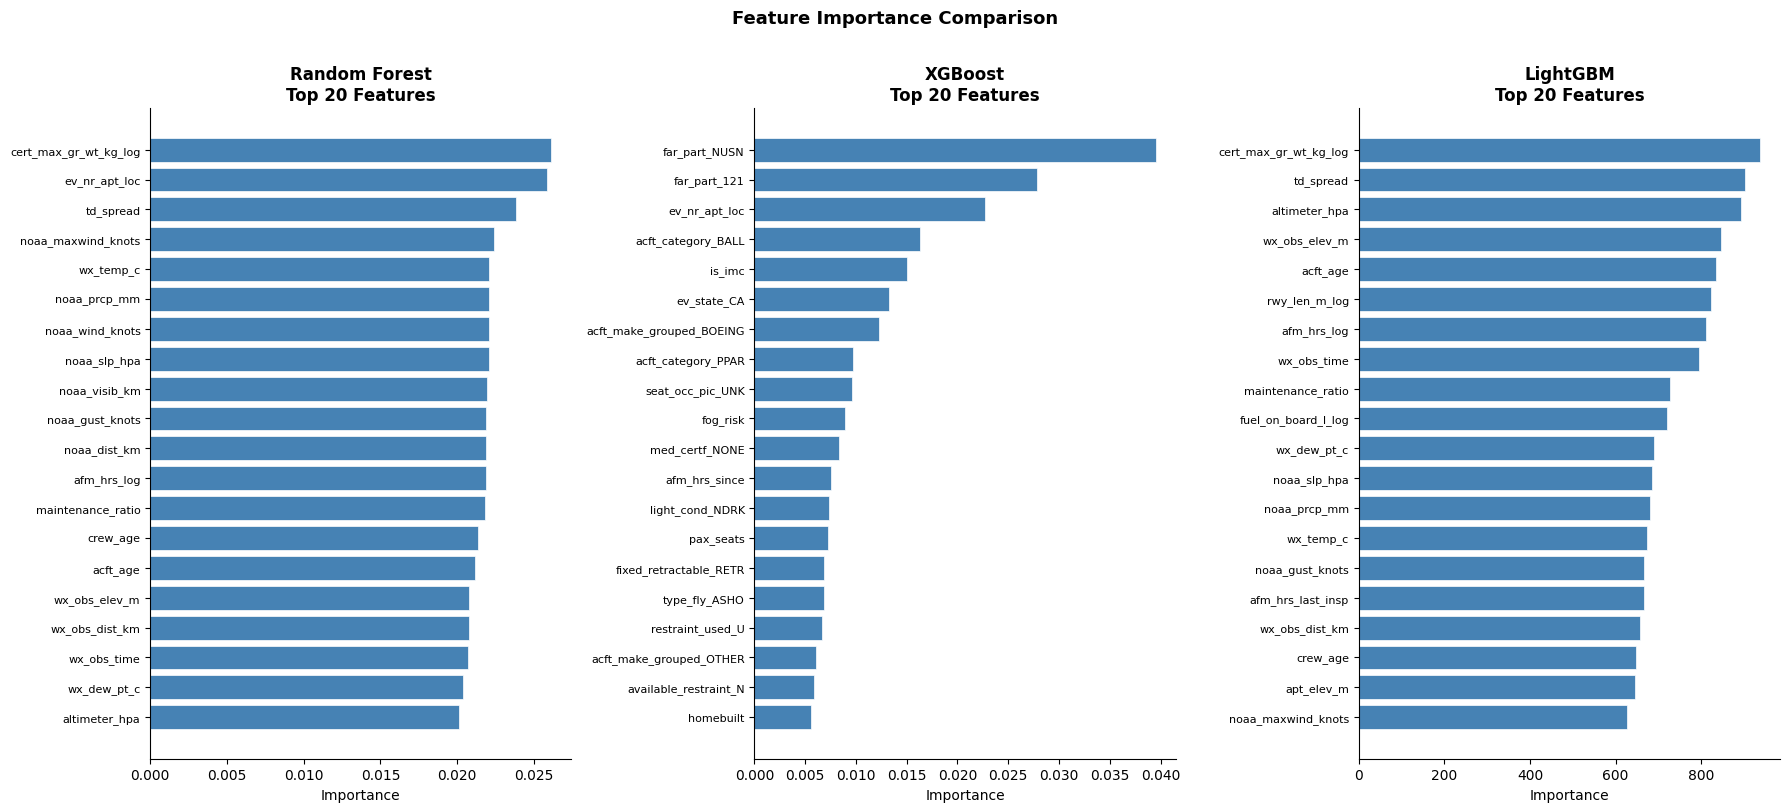

In [20]:
try:
    feature_names = pd.read_csv(f'{OUTPUT_DIR}/feature_names.csv').squeeze().tolist()
except:
    feature_names = [f'f{i}' for i in range(X_train.shape[1])]

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
tree_models_fi = [
    (rf,        'Random Forest',  'feature_importances_'),
    (xgb_model, 'XGBoost',        'feature_importances_'),
    (lgb_model, 'LightGBM',       'feature_importances_'),
]
for ax, (model, name, attr) in zip(axes, tree_models_fi):
    imps = getattr(model, attr)
    top_idx   = np.argsort(imps)[-20:][::-1]
    top_names = [feature_names[i] if i < len(feature_names) else f'f{i}' for i in top_idx]
    top_vals  = imps[top_idx]
    ax.barh(range(20), top_vals[::-1], color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(20)); ax.set_yticklabels(top_names[::-1], fontsize=8)
    ax.set_title(f'{name}\nTop 20 Features', fontweight='bold')
    ax.set_xlabel('Importance')
    sns.despine(ax=ax)

plt.suptitle('Feature Importance Comparison', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/feature_importance_top20.png', dpi=150, bbox_inches='tight')
plt.show()


In [21]:
print(f'  Models trained       : 6')
print(f'  CV folds             : {N_CV_FOLDS}-fold stratified')
print(f'  Best model (val)     : {best_model_name}')
print(f'  Best val FATL recall : {results_df.iloc[0]["fatl_recall"]:.4f}')
print(f'  Test macro F1        : {metrics_test["macro_f1"]:.4f}')
print(f'  Test FATL recall     : {metrics_test["fatl_recall"]:.4f}')
print()
for f in sorted(os.listdir(MODEL_DIR)):
    print(f'    {f}')


  Models trained       : 6
  CV folds             : 5-fold stratified
  Best model (val)     : XGBoost
  Best val FATL recall : 0.6944
  Test macro F1        : 0.4606
  Test FATL recall     : 0.5644

    best_model.pkl
    catboost.pkl
    cm_catboost_val.png
    cm_lightgbm_val.png
    cm_logistic_regression_val.png
    cm_mlp_val.png
    cm_random_forest_val.png
    cm_xgboost_test.png
    cm_xgboost_val.png
    cv_comparison.png
    cv_results.csv
    feature_importance_top20.png
    lightgbm.pkl
    logistic_regression.pkl
    mlp.pkl
    model_comparison.png
    random_forest.pkl
    val_comparison.csv
    xgboost.pkl


## 8. Interpretation

### From an optimistic to an honest evaluation
Each methodological fix removed a source of optimism (XGBoost, test set):

| Version | Split | Features | Test FATL recall | Test macro-F1 |
|---|---|---|---|---|
| initial | random, stratified | with post-accident variables | 0.880 | 0.582 |
| step 1 | random, stratified | post-accident variables removed | 0.735 | 0.513 |
| **current** | **temporal** | + missingness indicators removed | **0.564** | **0.461** |

- The first drop is the **target leakage** (`crew_tox_perf`, an autopsy test, was the #1 feature).
- The second drop is **temporal generalisation**: trained on 2008–2018, the model loses accuracy
  on 2022–2026 (CV 0.731 → val 0.694 → test 0.564 FATL recall). The share of fatal accidents also
  falls from 21.4 % (train) to 17.9 % (test), and the circumstances of accidents evolve.
  A random split hid this, because train and test were drawn from the same years.

### Model comparison
- **XGBoost, LightGBM and CatBoost are within 0.006 of each other** on validation FATL recall
  (0.694 / 0.689 / 0.692); XGBoost is kept, LightGBM has a slightly better macro-F1 (0.473).
- **Random Forest has the best accuracy (0.61 on val)** but a much lower FATL recall: it favours the
  majority class `NONE` — accuracy is the wrong target here.
- **The MLP is last** (FATL recall 0.44 on val): unlike the other models it receives no class weights.

### Per-class behaviour (test set)
`NONE` is recognised reasonably well (F1 0.70), `FATL` moderately (F1 0.52, recall 0.56);
the intermediate classes `MINR` and `SERS` remain hard (F1 0.26 and 0.37).

### Most important features (XGBoost, gain)
Type of operation (`far_part_NUSN`, `far_part_121`), distance to an airport (`ev_nr_apt_loc`),
aircraft category (balloons, powered parachutes), instrument conditions (`is_imc`), fog risk and
state. All of them are known before the flight.

### Ways to improve
Retrain on 2008–2021 once the model is chosen (the most recent years are the most informative),
tune hyper-parameters on a time-based validation, and add pre-flight information that is still
missing (pilot total flight hours, recent experience).